In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# прочитаем наши данные из файла и запишем в переменную
df = pd.read_csv('C:/Users/majkl/WorkSpace/Online_store_sales_Analysis/sales_data.csv')
# выведем инофрмацию о датафрейме
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   product_category  500 non-null    object 
 3   revenue           500 non-null    float64
 4   order_date        500 non-null    object 
 5   country           500 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 23.6+ KB


,order_id,customer_id,product_category,revenue,order_date,country
0,1,103,Красота,286.20,2023-01-01 00:00:00.000000000,Германия
1,2,72,Электроника,187.12,2023-01-01 17:30:25.250501002,США
2,3,75,Книги,262.53,2023-01-02 11:00:50.501002004,Германия
3,4,150,Электроника,291.57,2023-01-03 04:31:15.751503006,США
4,5,38,Одежда,70.91,2023-01-03 22:01:41.002004008,Россия


In [5]:
# поиск дублей записей
print(df.isnull().sum())

order_id            0
customer_id         0
product_category    0
revenue             0
order_date          0
country             0
dtype: int64


##### Дублей не обнаружено, записи в нужном виде для анализа, можно перейти к нахождению основных метрик

In [11]:
df['revenue'].describe().round(2)

count    500.00
mean     160.02
std       82.96
min       20.34
25%       87.71
50%      158.28
75%      235.63
max      299.82
Name: revenue, dtype: float64

#####  используем альтернативный вариант с добавлением нужных метрик 

In [14]:
total_revenue = df['revenue'].sum()
total_orders = len(df)
avg_order_value = df['revenue'].mean()
unique_customers = df['customer_id'].nunique()

print(f"• Общая выручка: {total_revenue:,.2f}")
print(f"• Всего заказов: {total_orders}")
print(f"• Средний чек: {avg_order_value:.2f}")
print(f"• Уникальных клиентов: {unique_customers}")

• Общая выручка: 80,007.89
• Всего заказов: 500
• Средний чек: 160.02
• Уникальных клиентов: 181


### Проанализируем категории товаров

In [19]:
category_analysis = df.groupby('product_category').agg({
    'revenue': ['sum', 'count', 'mean']
}).round(2)

category_analysis.columns = ['Выручка_итого', 'Количество_заказов', 'Средний_чек']
category_analysis['Доля_выручки_%'] = (category_analysis['Выручка_итого'] / category_analysis['Выручка_итого'].sum() * 100).round(1)

print(category_analysis)

# Находим самую прибыльную категорию
best_category = category_analysis['Выручка_итого'].idxmax()
best_category_revenue = category_analysis['Выручка_итого'].max()
print(f"\n Самая прибыльная категория: {best_category} ({best_category_revenue:,.2f})")

                  Выручка_итого  Количество_заказов  Средний_чек  \
product_category                                                   
Книги                  21641.97                 128       169.08   
Красота                20172.48                 121       166.71   
Одежда                 18898.66                 122       154.91   
Электроника            19294.78                 129       149.57   

                  Доля_выручки_%  
product_category                  
Книги                       27.0  
Красота                     25.2  
Одежда                      23.6  
Электроника                 24.1  

 Самая прибыльная категория: Книги (21,641.97)


### Проанализируем данные по странам

In [20]:
country_analysis = df.groupby('country').agg({
    'revenue': ['sum', 'count', 'mean'],
    'customer_id': 'nunique'
}).round(2)

country_analysis.columns = ['Выручка_итого', 'Количество_заказов', 'Средний_чек', 'Уникальные_клиенты']
print(country_analysis)

# Страна с самым высоким средним чеком
best_country_avg = country_analysis['Средний_чек'].idxmax()
best_avg_value = country_analysis['Средний_чек'].max()
print(f"\n Самый высокий средний чек: {best_country_avg} ({best_avg_value:.2f})")

          Выручка_итого  Количество_заказов  Средний_чек  Уникальные_клиенты
country                                                                     
Германия       26839.62                 162       165.68                 115
Россия         27867.21                 180       154.82                 121
США            25301.06                 158       160.13                 105

 Самый высокий средний чек: Германия (165.68)


### Проверим динамику по месяцам

In [30]:
# Добавляем месяц к данным
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month

monthly_analysis = df.groupby('month').agg({
    'revenue': 'sum',
    'order_id': 'count'
}).round(2)

monthly_analysis.columns = ['Выручка', 'Количество_заказов']

# Словарь для названий месяцев
month_names = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
    5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
    9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}

print(monthly_analysis)

# Самый прибыльный месяц
best_month_num = monthly_analysis['Выручка'].idxmax()
best_month_name = month_names[best_month_num]
best_month_revenue = monthly_analysis['Выручка'].max()

print(f"\nСамый прибыльный месяц: {best_month_num} ({best_month_name}) - {best_month_revenue:,.2f}")

       Выручка  Количество_заказов
month                             
1      7283.69                  43
2      5239.61                  38
3      6575.47                  43
4      7130.12                  41
5      7521.08                  43
6      6127.44                  41
7      7458.46                  42
8      6717.45                  43
9      6358.30                  41
10     7456.85                  42
11     6068.90                  41
12     6070.52                  42

Самый прибыльный месяц: 5 (Май) - 7,521.08


### Добавим визуализацию рассчетов

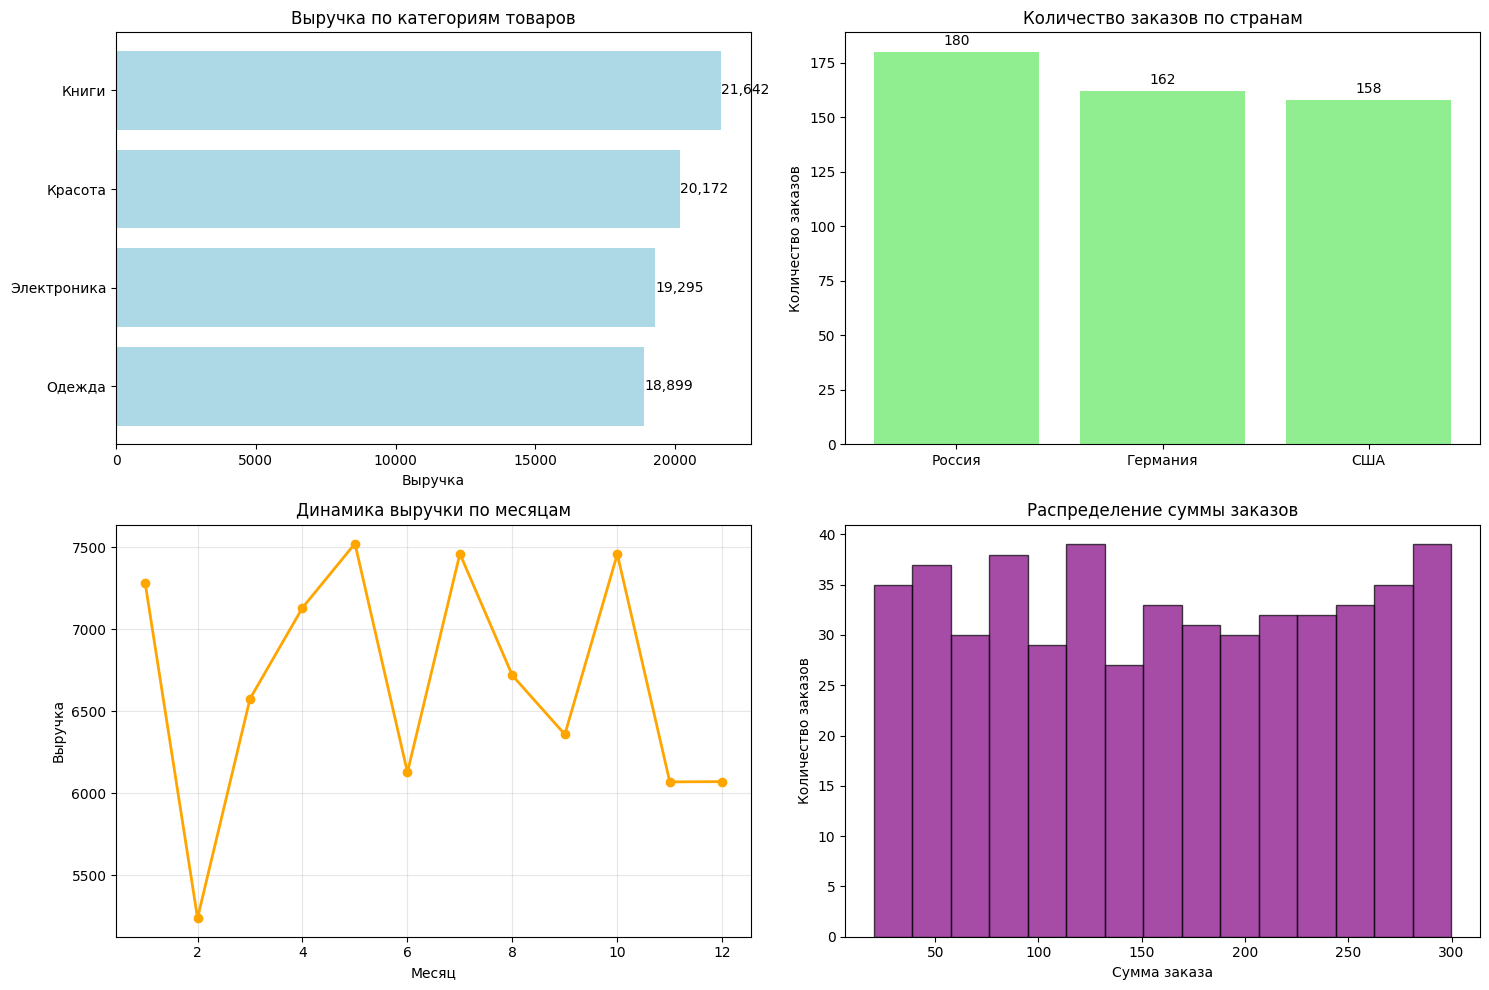

In [32]:
# Создаем сетку графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Выручка по категориям
category_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=True)
bars1 = axes[0, 0].barh(category_revenue.index, category_revenue.values, color='lightblue')
axes[0, 0].set_title('Выручка по категориям товаров')
axes[0, 0].set_xlabel('Выручка')

# Добавляем значения на столбцы
for bar in bars1:
    width = bar.get_width()
    axes[0, 0].text(width + 5, bar.get_y() + bar.get_height()/2, 
                   f'{width:,.0f}', ha='left', va='center')

# 2. Количество заказов по странам
country_orders = df['country'].value_counts()
bars2 = axes[0, 1].bar(country_orders.index, country_orders.values, color='lightgreen')
axes[0, 1].set_title('Количество заказов по странам')
axes[0, 1].set_ylabel('Количество заказов')

# Добавляем значения на столбцы
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, height + 2, 
                   f'{height:.0f}', ha='center', va='bottom')

# 3. Динамика выручки по месяцам
monthly_revenue = df.groupby('month')['revenue'].sum()
axes[1, 0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, color='orange')
axes[1, 0].set_title('Динамика выручки по месяцам')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Выручка')
axes[1, 0].grid(True, alpha=0.3)

# 4. Распределение суммы заказов
axes[1, 1].hist(df['revenue'], bins=15, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_title('Распределение суммы заказов')
axes[1, 1].set_xlabel('Сумма заказа')
axes[1, 1].set_ylabel('Количество заказов')

plt.tight_layout()
plt.savefig('sales_analysis_results.png', dpi=300, bbox_inches='tight')
plt.show()

### Считаем дополнительные метрики

In [33]:

russia_orders = len(df[df['country'] == 'Россия'])
russia_percent = (russia_orders / len(df)) * 100

electronics_orders = len(df[df['product_category'] == 'Электроника'])
electronics_percent = (electronics_orders / len(df)) * 100

# Выводим данные
insights = [
    f"1. {best_category} приносит {category_analysis.loc[best_category, 'Доля_выручки_%']}% всей выручки",
    f"2. {russia_percent:.1f}% заказов поступает из России",
    f"3. В {best_country_avg} самый высокий средний чек ({best_avg_value:.2f})",
    f"4. Самый прибыльный месяц - {best_month} ({best_month_revenue:,.2f})",
    f"5. {electronics_percent:.1f}% заказов в категории 'Электроника'"
]

for insight in insights:
    print(f"• {insight}")

• 1. Книги приносит 27.0% всей выручки
• 2. 36.0% заказов поступает из России
• 3. В Германия самый высокий средний чек (165.68)
• 4. Самый прибыльный месяц - 5 (7,521.08)
• 5. 25.8% заказов в категории 'Электроника'


### Возможные рекомендации

In [34]:
recommendations = [
    f"• Инвестировать в развитие категории '{best_category}'",
    f"• Изучить успешный опыт {best_country_avg} для других рынков",
    f"• Повторить маркетинговые стратегии месяца {best_month}",
    f"• Укрепить позиции в России ({russia_percent:.1f}% заказов)",
    f"• Расширять ассортимент в категории 'Электроника'"
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

1. • Инвестировать в развитие категории 'Книги'
2. • Изучить успешный опыт Германия для других рынков
3. • Повторить маркетинговые стратегии месяца 5
4. • Укрепить позиции в России (36.0% заказов)
5. • Расширять ассортимент в категории 'Электроника'
